# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test10 solar earth

Notebook equivalent of `tests/4_earth/test10_solar_earth.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test10_solar_earth"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test10_solar_earth.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test10_solar_earth


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_solar_mass_weights_are_normalized`

**What is checked:** Solar mass weights are normalized behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: solar mass weights must have shape (NE, 3); solar mass weights must sum to one; solar mass weights must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [4]:
run_notebook_test(TEST_MODULE.test_solar_mass_weights_are_normalized)


Running test_solar_mass_weights_are_normalized ...

solar mass weights from source production:
tensor([[5.9511733179e-01, 3.9477229313e-01, 1.0110375085e-02],
        [5.0765202268e-01, 4.8212539001e-01, 1.0222587307e-02],
        [2.6933562517e-01, 7.2009371304e-01, 1.0570661798e-02],
        [9.2595214229e-02, 8.9621320287e-01, 1.1191582900e-02],
        [4.1706027811e-02, 9.4642514340e-01, 1.1868828787e-02]], dtype=torch.float64)
weight sums: tensor([1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_solar_mass_weights_are_normalized


## Test: `test_initial_neutrino_antineutrino_match_for_same_mass_weights`

**What is checked:** Initial neutrino antineutrino match for same mass weights behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Initial nu/antinu flavour probabilities match for identical mass weights.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_initial_neutrino_antineutrino_match_for_same_mass_weights)


Running test_initial_neutrino_antineutrino_match_for_same_mass_weights ...

Initial flavour probabilities before earth:
neutrino    : tensor([[5.2594377352e-01, 1.9723914912e-01, 2.7681707736e-01],
        [4.9460947046e-01, 2.1849287082e-01, 2.8689765873e-01],
        [4.0922005707e-01, 2.7641230839e-01, 3.1436763454e-01],
        [3.4578244974e-01, 3.1944800858e-01, 3.3476954168e-01],
        [3.2736417901e-01, 3.3195125063e-01, 3.4068457037e-01]], dtype=torch.float64)
antineutrino: tensor([[5.2594377352e-01, 1.9723914912e-01, 2.7681707736e-01],
        [4.9460947046e-01, 2.1849287082e-01, 2.8689765873e-01],
        [4.0922005707e-01, 2.7641230839e-01, 3.1436763454e-01],
        [3.4578244974e-01, 3.1944800858e-01, 3.3476954168e-01],
        [3.2736417901e-01, 3.3195125063e-01, 3.4068457037e-01]], dtype=torch.float64)
max |nu - antinu| before earth = 0.000000e+00
------------------------------------------------------------------------------------------
PASSED: test_initial_neutrino_a

## Test: `test_final_probabilities_are_normalized_for_each_eta`

**What is checked:** Final probabilities are normalized for each eta behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [6]:
run_notebook_test(TEST_MODULE.test_final_probabilities_are_normalized_for_each_eta)


Running test_final_probabilities_are_normalized_for_each_eta ...

Final probability sums for neutrino:
tensor([[1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00],
        [1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00],
        [1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00],
        [1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00],
        [1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00]], dtype=torch.float64)
max normalization error = 6.661338e-16

Final probability sums for antineutrino:
tensor([[1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00],
        [1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00],
        [1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00],
        [1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00],
        [1.0000000000e+00, 1.0000000000e+00, 1.000000000

## Test: `test_neutrino_antineutrino_earth_difference_is_finite`

**What is checked:** Neutrino antineutrino earth difference is finite behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Neutrino-antineutrino earth differences must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_neutrino_antineutrino_earth_difference_is_finite)


Running test_neutrino_antineutrino_earth_difference_is_finite ...

Neutrino vs antineutrino after earth:
max absolute probability difference: 6.072540e-02
mean absolute probability difference: 7.276886e-03
------------------------------------------------------------------------------------------
PASSED: test_neutrino_antineutrino_earth_difference_is_finite


## Plot: `plot_initial_flux_comparison()`

**What is checked:** Initial flux comparison behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_solar_initial_nu_antinu_spectra.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_initial_flux_comparison()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_solar_initial_nu_antinu_spectra.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_initial_flux_comparison() ...
Saved plot: V:\output\test\earth\test10_solar_earth\plot_initial_flux_comparison_figure_001.png


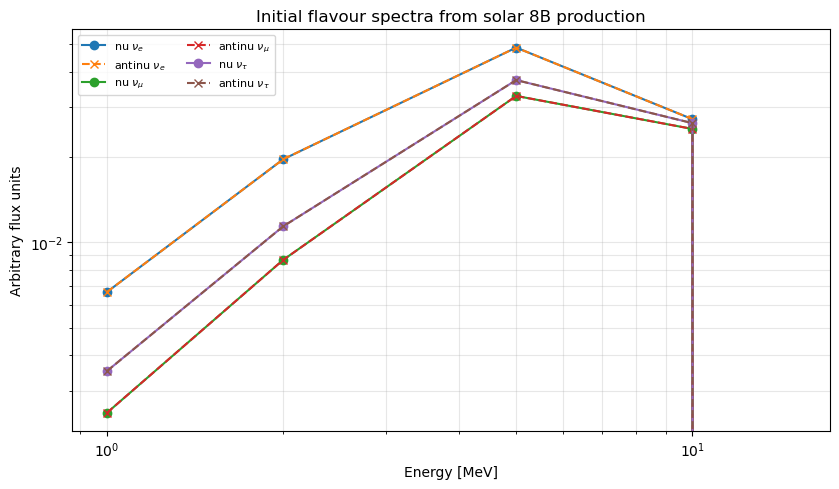

PASSED: plot_initial_flux_comparison()


In [8]:
run_notebook_call('plot_initial_flux_comparison()', lambda: TEST_MODULE.plot_initial_flux_comparison())


## Plot: `plot_final_flux_by_eta()`

**What is checked:** Final flux by eta behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_solar_final_spectra_by_eta.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_final_flux_by_eta()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_solar_final_spectra_by_eta.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_final_flux_by_eta() ...
Saved plot: V:\output\test\earth\test10_solar_earth\plot_final_flux_by_eta_figure_001.png


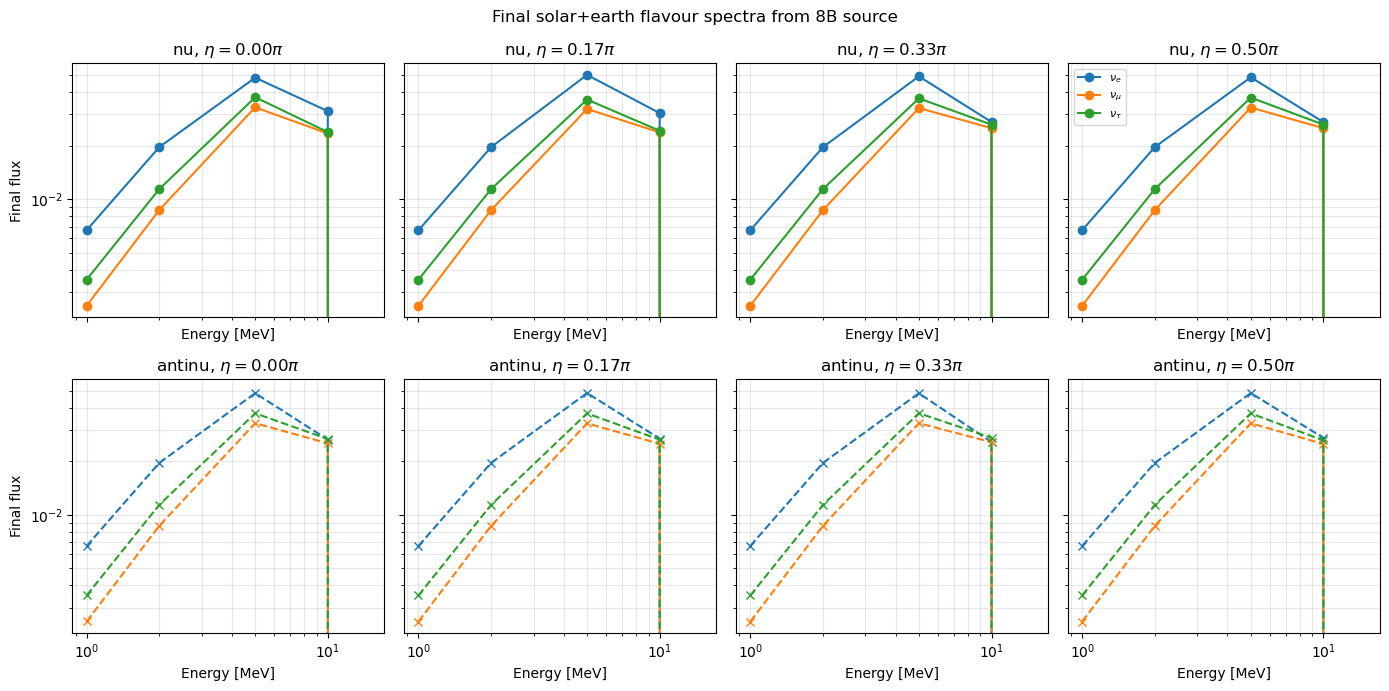

PASSED: plot_final_flux_by_eta()


In [9]:
run_notebook_call('plot_final_flux_by_eta()', lambda: TEST_MODULE.plot_final_flux_by_eta())


## Plot: `plot_neutrino_antineutrino_difference()`

**What is checked:** Neutrino antineutrino difference behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_solar_nu_antinu_probability_difference.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_neutrino_antineutrino_difference()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_solar_nu_antinu_probability_difference.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_neutrino_antineutrino_difference() ...
Saved plot: V:\output\test\earth\test10_solar_earth\plot_neutrino_antineutrino_difference_figure_001.png


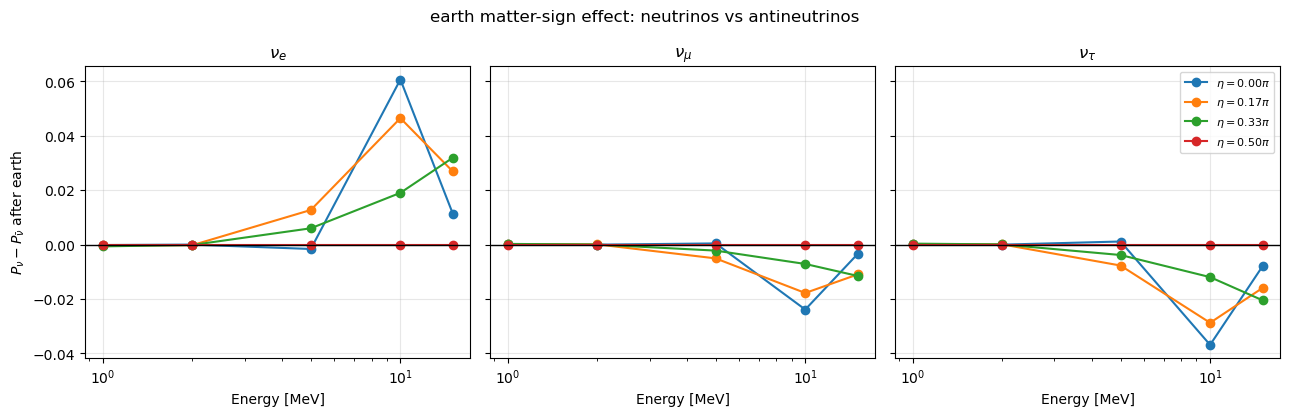

PASSED: plot_neutrino_antineutrino_difference()


In [10]:
run_notebook_call('plot_neutrino_antineutrino_difference()', lambda: TEST_MODULE.plot_neutrino_antineutrino_difference())
